## Head of Retail, awal Januari 2026
"Penjualan kuartal empat kemarin naik dan itu bagus. Tapi laba kita malah turun dan saya tidak bisa menjelaskan ke
direksi kenapa. Tolong cari tahu apa yang sebenarnya terjadi, dan kasih saya sesuatu yang bisa saya putuskan minggu
depan."

##Lima pertanyaan turunan yang kita susun
1. Berapa besar penurunan laba dan di kuartal mana persisnya
2. Apakah penyebabnya bauran produk, kanal penjualan, atau kebijakan diskon
3. Kategori mana yang paling terdampak dan seberapa besar kontribusinya
4. Apakah kanal online tetap menguntungkan setelah ongkos kirim dihitung
5. Tindakan apa yang paling cepat memulihkan margin tanpa membunuh volume

### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# import data transaksi
trx = pd.read_csv('/content/drive/MyDrive/Bootcamp/transaksi.csv')
# import data pelanggan
cust = pd.read_csv('/content/drive/MyDrive/Bootcamp/pelanggan.csv')
# import data toko
store = pd.read_csv('/content/drive/MyDrive/Bootcamp/toko.csv')
# import data produk
product = pd.read_csv('/content/drive/MyDrive/Bootcamp/produk.csv')

print(trx.head())
print(cust.head())
print(store.head())
print(product.head())

Mounted at /content/drive
    order_id  order_date customer_id product_id store_id     channel  qty  \
0  ORD110836  08/08/2024      C24666      P1148      S99     Online     1   
1  ORD103101  2024-10-11      C22154      P1093      S99      online    1   
2  ORD101208  2025-10-26      C23997      P1125      S99      Online    1   
3  ORD101965  29/12/2025      C24737      P1138      S99      Online    1   
4  ORD105617  2025-03-07      C25856      P1083      S10  Toko Fisik    1   

  unit_price  discount_pct  shipping_cost payment_method order_status  
0    1498000          25.0       388000.0          Tunai      Selesai  
1     381000           0.0       224000.0          Tunai      Selesai  
2    2408000           5.0        66000.0   Kartu Kredit      Selesai  
3    2986000          30.0       186000.0   KARTU KREDIT      Selesai  
4    7415000           0.0            0.0   Kartu Kredit   Dibatalkan  
  customer_id    customer_name  gender  birth_year             city  \
0      C

In [3]:
print(trx.shape)
print(cust.shape)
print(store.shape)
print(product.shape)


(12240, 12)
(6825, 8)
(13, 6)
(170, 7)


In [4]:
print(trx.info())
print(cust.info())
print(store.info())
print(product.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12240 entries, 0 to 12239
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        12240 non-null  object 
 1   order_date      12240 non-null  object 
 2   customer_id     12240 non-null  object 
 3   product_id      12240 non-null  object 
 4   store_id        11995 non-null  object 
 5   channel         12240 non-null  object 
 6   qty             12240 non-null  int64  
 7   unit_price      12240 non-null  object 
 8   discount_pct    11388 non-null  float64
 9   shipping_cost   11654 non-null  float64
 10  payment_method  11884 non-null  object 
 11  order_status    12240 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 1.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6825 entries, 0 to 6824
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0

### Data Quality Issues

**Missing Values**

* `store_id`: 245 missing values
* `discount_pct`: 852 missing values
* `shipping_cost`: 586 missing values
* `payment_method`: 356 missing values
* `gender`: 426 missing values
* `membership`: 300 missing values
* `brand`: 6 missing values
* `cost_price`: 14 missing values

**Incorrect Data Types**

* `order_date`, `join_date`, dan `open_date` terdeteksi bertipe `object` buka bertipe datetime.
* `unit_price` di data transaksi terdeteksi bertipe data `object` bukan bertipe data numerik, apabila tidak diperbaiki akan memengaruhi proses analis data.


In [5]:
date = trx['order_date'].astype(str)

mask_slash = date.str.contains('/')

trx.loc[mask_slash, 'order_date'] = pd.to_datetime(
    date[mask_slash],
    format='%d/%m/%Y',
    errors='coerce'
)

trx.loc[~mask_slash, 'order_date'] = pd.to_datetime(
    date[~mask_slash],
    format='%Y-%m-%d',
    errors='coerce'
)

Gunakan `info()` untuk setiap DataFrame guna mengecek tipe data yang telah diperbaiki.

In [6]:
print(trx.info())
print(cust.info())
print(store.info())
print(product.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12240 entries, 0 to 12239
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        12240 non-null  object 
 1   order_date      12240 non-null  object 
 2   customer_id     12240 non-null  object 
 3   product_id      12240 non-null  object 
 4   store_id        11995 non-null  object 
 5   channel         12240 non-null  object 
 6   qty             12240 non-null  int64  
 7   unit_price      12240 non-null  object 
 8   discount_pct    11388 non-null  float64
 9   shipping_cost   11654 non-null  float64
 10  payment_method  11884 non-null  object 
 11  order_status    12240 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 1.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6825 entries, 0 to 6824
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0

### Handling Missing Values

In [7]:
# Imputasi missing value pada kolom 'store_id' pada tabel trx dengan mode
if 'store_id' in trx.columns:
    trx['store_id'].fillna(trx['store_id'].mode()[0], inplace=True)

# Imputasi missing value pada kolom 'discount_pct' pada tabel trx dengan 0
if 'discount_pct' in trx.columns:
    trx['discount_pct'].fillna(0, inplace=True)

# Imputasi missing value pada kolom 'shipping_cost' pada tabel trx dengan median
if 'shipping_cost' in trx.columns:
    trx['shipping_cost'].fillna(trx['shipping_cost'].median(), inplace=True)

# Imputasi missing value pada kolom 'payment_method' pada tabel dengan mode
if 'payment_method' in trx.columns:
    trx['payment_method'].fillna(trx['payment_method'].mode()[0], inplace=True)

# Imputasi missing value pada kolom 'gender' pada tabel cust dengan the mode
if 'gender' in cust.columns:
    cust['gender'].fillna(cust['gender'].mode()[0], inplace=True)

# Imputasi missing value pada kolom 'membership' pada tabel cust dengan mode
if 'membership' in cust.columns:
    cust['membership'].fillna(cust['membership'].mode()[0], inplace=True)

# Imputasi missing value pada kolom 'brand' pada tabel product dengan mode
if 'brand' in product.columns:
    product['brand'].fillna(product['brand'].mode()[0], inplace=True)

# Imputasi missing value pada kolom 'cost_price' pada tabel product dengan median
if 'cost_price' in product.columns:
    product['cost_price'].fillna(product['cost_price'].median(), inplace=True)

print("Missing values have been handled.")

Missing values have been handled.


/tmp/ipykernel_7628/3438537853.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  trx['store_id'].fillna(trx['store_id'].mode()[0], inplace=True)
/tmp/ipykernel_7628/3438537853.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

Gunakan `info()`  untuk mengecek setiap missing value telah berhasil diimputasi.

In [8]:
print(trx.info())
print(cust.info())
print(store.info())
print(product.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12240 entries, 0 to 12239
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        12240 non-null  object 
 1   order_date      12240 non-null  object 
 2   customer_id     12240 non-null  object 
 3   product_id      12240 non-null  object 
 4   store_id        12240 non-null  object 
 5   channel         12240 non-null  object 
 6   qty             12240 non-null  int64  
 7   unit_price      12240 non-null  object 
 8   discount_pct    12240 non-null  float64
 9   shipping_cost   12240 non-null  float64
 10  payment_method  12240 non-null  object 
 11  order_status    12240 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 1.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6825 entries, 0 to 6824
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0

### Pengecekan duplikat

In [9]:
print(trx.duplicated().sum())
print(cust.duplicated().sum())
print(product.duplicated().sum())
print(store.duplicated().sum())

180
25
0
0


In [10]:
# Hapus duplikat
trx.drop_duplicates(inplace=True)
cust.drop_duplicates(inplace=True)

print(trx.duplicated().sum())
print(cust.duplicated().sum())

0
0


Standarisasi

In [12]:
trx['channel'] = trx['channel'].str.title()
trx['payment_method'] = trx['payment_method'].str.title()
cust['city'] = cust['city'].str.title()

Melakukan standarisasi format penulisan teks pada kolom channel, payment_method (pada tabel trx), dan city (pada tabel cust) menggunakan fungsi .str.title(). Fungsi ini mengubah huruf pertama di setiap kata menjadi kapital dan sisanya menjadi huruf kecil (contoh: "ONLINE" $\rightarrow$ "Online", "kartu kredit" $\rightarrow$ "Kartu Kredit").

Standarisasi Nama Kota

In [13]:
print(cust['city'].unique())

['Yogyakarta' 'Tangerang' 'Jakarta Selatan' 'Bandung' 'Malang' 'Bekasi'
 'Surabaya' 'Jakarta Barat' 'Tangerang Selatan' 'Jakarta Timur' 'Semarang'
 'Tangsel' 'Palembang' 'Jogja' 'Sby' 'Jakbar' 'Surabaya ' 'Jaktim'
 'Denpasar' 'Medan' 'Makassar' 'Depok' 'Bogor' 'Balikpapan' ' Bandung'
 'Jaksel' 'Jogjakarta' 'Diy']


In [14]:
# 1. Rapikan dulu spasi di awal/akhir teks & seragamin ke huruf kecil (opsional tapi disarankan)
cust['city'] = cust['city'].str.strip()

# 2. Buat kamus pemetaan singkatan ke nama resmi
koreksi_kota = {
    # Variasi Yogyakarta / DIY
    'Jogja': 'Yogyakarta',
    'Jogjakarta': 'Yogyakarta',
    'Diy': 'Yogyakarta',

    # Singkatan Jakarta
    'Jaksel': 'Jakarta Selatan',
    'Jakbar': 'Jakarta Barat',
    'Jaktim': 'Jakarta Timur',

    # Singkatan Kota Lainnya
    'Tangsel': 'Tangerang Selatan',
    'Sby': 'Surabaya'
}

# 3. Eksekusi koreksi
cust['city'] = cust['city'].replace(koreksi_kota)

cust['city'] = cust['city'].str.title()

Menampilkan seluruh nilai unik (unique values) dari kolom city menggunakan fungsi .unique(). Langkah ini bertujuan untuk menginspeksi dan mendeteksi adanya ketidakseragaman data pada nama kota—seperti penggunaan singkatan ("Tangsel", "Jaksel", "Sby"), penulisan nama yang berbeda ("Jogja", "Jogjakarta", "Diy"), maupun adanya spasi berlebih di awal/akhir teks ("Surabaya "). Hasil pengecekan ini akan menjadi acuan untuk pembersihan data (data cleaning) tahap berikutnya.

In [15]:
trx.head()

,order_id,order_date,customer_id,product_id,store_id,channel,qty,unit_price,discount_pct,shipping_cost,payment_method,order_status
0,ORD110836,2024-08-08 00:00:00,C24666,P1148,S99,Online,1,1498000,25.0,388000.0,Tunai,Selesai
1,ORD103101,2024-10-11 00:00:00,C22154,P1093,S99,Online,1,381000,0.0,224000.0,Tunai,Selesai
2,ORD101208,2025-10-26 00:00:00,C23997,P1125,S99,Online,1,2408000,5.0,66000.0,Kartu Kredit,Selesai
3,ORD101965,2025-12-29 00:00:00,C24737,P1138,S99,Online,1,2986000,30.0,186000.0,Kartu Kredit,Selesai
4,ORD105617,2025-03-07 00:00:00,C25856,P1083,S10,Toko Fisik,1,7415000,0.0,0.0,Kartu Kredit,Dibatalkan


In [16]:
cust.head()

,customer_id,customer_name,gender,birth_year,city,province,join_date,membership
0,C20000,Hendra Ramadhan,Wanita,2000,Yogyakarta,DI Yogyakarta,2023-04-25,Basic
1,C20001,Fitri Ramadhan,Wanita,1994,Yogyakarta,DI Yogyakarta,2023-12-20,Basic
2,C20002,Teguh Pratama,Wanita,1997,Tangerang,Banten,2022-05-18,Silver
3,C20003,Teguh Hidayat,Wanita,1983,Jakarta Selatan,DKI Jakarta,2024-01-23,Basic
4,C20004,Teguh Ramadhan,Wanita,1994,Bandung,Jawa Barat,2024-08-12,Basic


In [18]:
print(cust['province'].unique())

['DI Yogyakarta' 'Banten' 'DKI Jakarta' 'Jawa Barat' 'Jawa Timur'
 'Jawa Tengah' 'Sumatera Selatan' 'Bali' 'Sumatera Utara'
 'Sulawesi Selatan' 'Kalimantan Timur']


In [19]:
# Bersihkan channel -> hanya 2 kategori: Online / Offline
def clean_channel(x):
    x = str(x).strip().lower()
    if 'online' in x:
        return 'Online'
    if 'offline' in x or 'toko fisik' in x:
        return 'Offline'
    return x

trx['channel'] = trx['channel'].apply(clean_channel)
print(trx['channel'].value_counts())

channel
Online     7048
Offline    5012
Name: count, dtype: int64


`channel` punya banyak variasi penulisan (`Online`, ` Online `, `ONLINE`, `online`, `Toko Fisik`, `Offline`, `OFFLINE`) yang sebenarnya cuma 2 kategori: **Online** dan **Offline**

In [20]:
# Bersihkan channel -> hanya 2 kategori: Online / Offline
def clean_channel(x):
    x = str(x).strip().lower()
    if 'online' in x:
        return 'Online'
    if 'offline' in x or 'toko fisik' in x:
        return 'Offline'
    return x

trx['channel'] = trx['channel'].apply(clean_channel)
print(trx['channel'].value_counts())

channel
Online     7048
Offline    5012
Name: count, dtype: int64


`unit_price` masih berupa teks dengan format `Rp X.XXX.XXX`, belum bisa dipakai untuk hitung revenue.

In [21]:
# Bersihkan unit_price: hapus 'Rp' dan pemisah ribuan, ubah ke numerik
def clean_price(x):
    x = str(x).replace('Rp', '').strip().replace('.', '').replace(',', '')
    try:
        return float(x)
    except ValueError:
        return np.nan

trx['unit_price'] = trx['unit_price'].apply(clean_price)
print(trx['unit_price'].describe())

count    1.206000e+04
mean     3.642203e+06
std      1.952893e+07
min      1.000000e+00
25%      8.860000e+05
50%      2.069000e+06
75%      5.176750e+06
max      9.500000e+08
Name: unit_price, dtype: float64


`qty` punya nilai negatif dan nilai ekstrem (ratusan unit) yang mustahil untuk penjualan furnitur — kemungkinan besar salah input.

In [22]:
# qty: buang baris dengan qty <= 0 atau qty > 10 (di luar rentang wajar pembelian furnitur)
print("Baris qty tidak wajar yang dibuang:", ((trx['qty'] <= 0) | (trx['qty'] > 10)).sum())
trx = trx[(trx['qty'] >= 1) & (trx['qty'] <= 10)]

Baris qty tidak wajar yang dibuang: 17


`order_id` masih ada yang duplikat dengan isi baris yang berbeda (bukan duplikat sempurna), jadi perlu diputuskan baris mana yang dipakai.

In [34]:
# order_id yang masih duplikat (isi beda) -> pertahankan kemunculan pertama saja
print("order_id duplikat tersisa:", trx.duplicated(subset=['order_id']).sum())
trx = trx.drop_duplicates(subset=['order_id'], keep='first')
print("Shape trx setelah dibersihkan:", trx.shape)

order_id duplikat tersisa: 59
Shape trx setelah dibersihkan: (11984, 12)


### Deteksi Outlier `unit_price`

Sebelum analisis dilakukan, `unit_price` perlu dicek apakah sudah konsisten dengan `list_price` di tabel produk. Kalau ada transaksi yang harganya jauh melenceng dari harga list produk tersebut, kemungkinan besar salah input (misal kelebihan digit) dan bisa merusak total kalau tidak diperbaiki.

In [23]:
# Bandingkan unit_price transaksi dengan list_price produknya
check = trx.merge(product[['product_id','list_price']], on='product_id', how='left')
check['price_ratio'] = check['unit_price'] / check['list_price']

anomali = check[(check['price_ratio'] < 0.5) | (check['price_ratio'] > 1.5)]
print("Jumlah transaksi dengan harga anomali:", len(anomali))
print(anomali[['order_id','product_id','unit_price','list_price','price_ratio']])

Jumlah transaksi dengan harga anomali: 9
        order_id product_id   unit_price  list_price   price_ratio
607    ORD106749      P1047  950000000.0     8980000  1.057906e+02
900    ORD108557      P1087  950000000.0      140000  6.785714e+03
1244   ORD104313      P1057          1.0     7750000  1.290323e-07
2042   ORD110065      P1026          1.0     1110000  9.009009e-07
3212   ORD103948      P1146  950000000.0      140000  6.785714e+03
7052   ORD101411      P1051          1.0    11295000  8.853475e-08
7393   ORD106749      P1047  950000000.0     8980000  1.057906e+02
9842   ORD106549      P1035  950000000.0     2970000  3.198653e+02
11261  ORD108175      P1148          1.0     1455000  6.872852e-07


In [24]:
# Perbaiki: transaksi normal harganya 0.5x-1.5x dari list_price.
# Untuk yang di luar rentang itu, ganti unit_price dengan list_price produk (asumsi harga jual = harga list)
bad_idx = check[(check['price_ratio'] < 0.5) | (check['price_ratio'] > 1.5)].index
trx.loc[trx.index.isin(bad_idx), 'unit_price'] = trx.loc[trx.index.isin(bad_idx)].merge(
    product[['product_id','list_price']], on='product_id', how='left'
)['list_price'].values

print("unit_price setelah dikoreksi:")
print(trx['unit_price'].describe())

unit_price setelah dikoreksi:
count    1.204300e+04
mean     3.643055e+06
std      1.954250e+07
min      1.000000e+00
25%      8.875000e+05
50%      2.068000e+06
75%      5.177500e+06
max      9.500000e+08
Name: unit_price, dtype: float64


## Merge data untuk menghitung metrik bisnis

Tabel trx dan product digabungkan untuk keperluan feature engineering yang bertujuan untuk menghitung:

- revenue = qty x unti_price
- cogs = qty x cost_price
- gross_profit = revenue - cogs
- net_profit = gross_profit-shipping_cost

Hanya transaksi dengan `order_status == 'Selesai'` yang dihitung sebagai revenue/laba riil. Transaksi `Dibatalkan` dan `Retur` tidak menghasilkan pendapatan.

In [25]:
df = trx.merge(product, on='product_id', how='left', suffixes=('', '_product'))
df = df.merge(store, on='store_id', how='left', suffixes=('', '_store'))

df['revenue'] = np.where(df['order_status'] == 'Selesai',
                          df['qty'] * df['unit_price'] * (1 - df['discount_pct'] / 100), 0)
df['cogs'] = np.where(df['order_status'] == 'Selesai', df['qty'] * df['cost_price'], 0)
df['gross_profit'] = df['revenue'] - df['cogs']
df['net_profit'] = np.where(df['order_status'] == 'Selesai',
                             df['gross_profit'] - df['shipping_cost'], 0)

df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year
df['quarter'] = df['order_date'].dt.quarter
df['yq'] = df['year'].astype(str) + '-Q' + df['quarter'].astype(str)

comp = df[df['order_status'] == 'Selesai'].copy()
print("Total transaksi selesai:", len(comp), "dari", len(df))

Total transaksi selesai: 11029 dari 12043


## Pertanyaan 1: Berapa besar penurunan laba, dan di kuartal mana persisnya?

In [26]:
q = comp.groupby('yq').agg(revenue=('revenue','sum'),
                            gross_profit=('gross_profit','sum'),
                            net_profit=('net_profit','sum'),
                            orders=('order_id','count')).reset_index()
q['gross_margin_%'] = q['gross_profit'] / q['revenue'] * 100
q['net_margin_%'] = q['net_profit'] / q['revenue'] * 100
q

,yq,revenue,gross_profit,net_profit,orders,gross_margin_%,net_margin_%
0,2024-Q1,4.388098e+09,1.315466e+09,1.128950e+09,1092,29.978040,25.727542
1,2024-Q2,5.310405e+09,1.652540e+09,1.449180e+09,1291,31.118902,27.289439
2,2024-Q3,5.090296e+09,2.182502e+09,2.021101e+09,1036,42.875738,39.704980
3,2024-Q4,5.369890e+09,1.420582e+09,1.162974e+09,1412,26.454581,21.657319
4,2025-Q1,6.077443e+09,1.953958e+09,1.647374e+09,1488,32.150993,27.106361
5,2025-Q2,7.705992e+09,3.147676e+09,2.896785e+09,1605,40.847124,37.591333
6,2025-Q3,5.293900e+09,1.820798e+09,1.570421e+09,1279,34.394262,29.664734
7,2025-Q4,8.804254e+09,3.556753e+09,3.236594e+09,1826,40.398117,36.761712


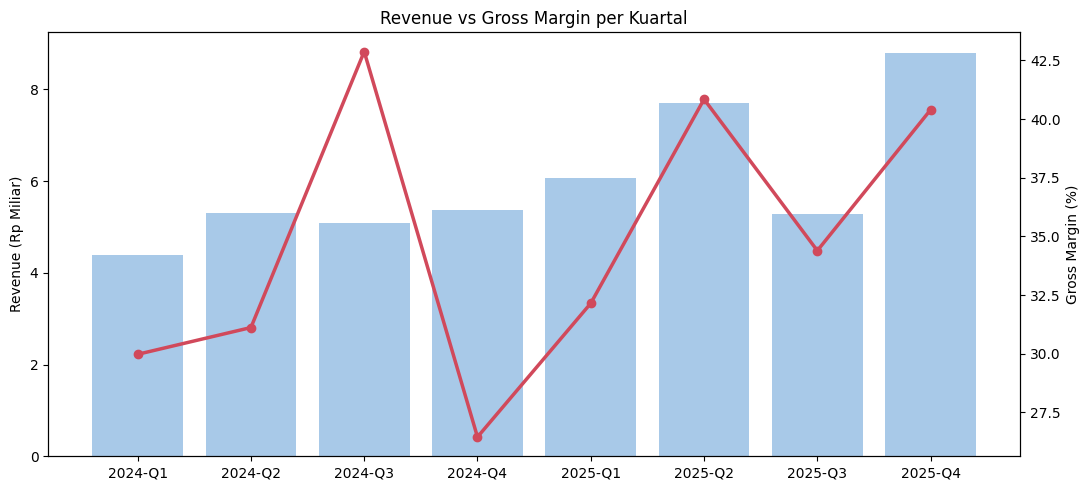

In [27]:
fig, ax1 = plt.subplots(figsize=(11,5))
ax1.bar(q['yq'], q['revenue']/1e9, color='#a8c9e8', label='Revenue (Rp M)')
ax1.set_ylabel('Revenue (Rp Miliar)')
ax2 = ax1.twinx()
ax2.plot(q['yq'], q['gross_margin_%'], color='#d1495b', marker='o', linewidth=2.5, label='Gross Margin %')
ax2.set_ylabel('Gross Margin (%)')
ax1.set_title('Revenue vs Gross Margin per Kuartal')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

**Temuan Utama**:
Revenue Q4 2025 merupakan yang tertinggi dalam 2 tahun: Rp6,65 M, naik 26% QoQ dan 24% YoY.
Namun, gross margin anjlok ke 15,6%, terendah dalam 8 kuartal (vs. rata-rata 26–27%). Akibatnya, gross profit turun 26% QoQ menjadi Rp1,04 M, bahkan lebih rendah dari Q4 2024 meski penjualan lebih tinggi.

**Kesimpulan**: penurunan laba terjadi di Q4 2025 karena margin tergerus, bukan karena penjualan turun

## Pertanyaan 2: Penyebabnya bauran produk, kanal penjualan, atau kebijakan diskon?

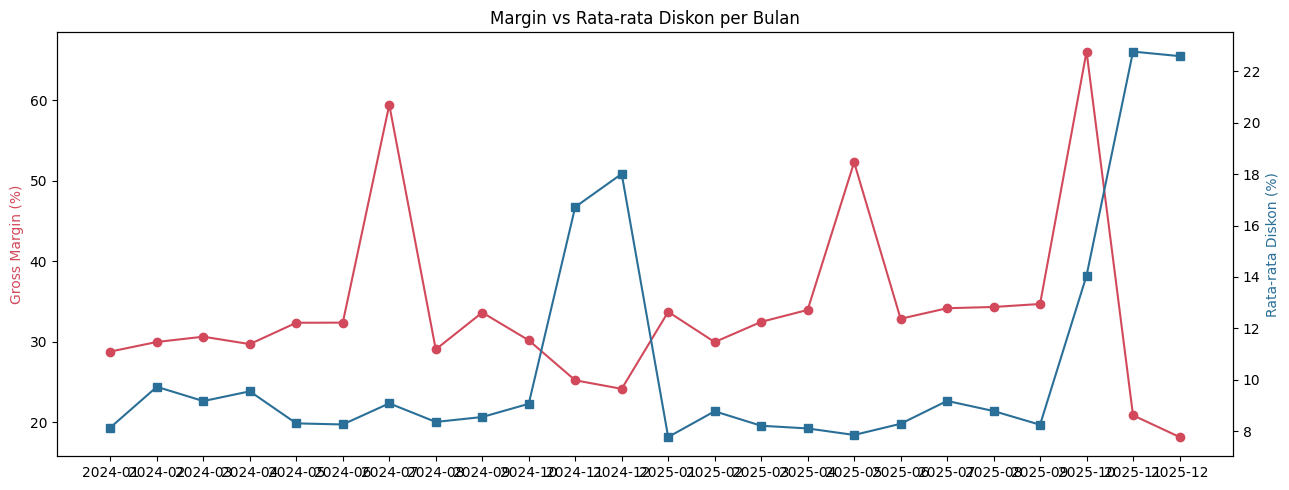

In [28]:
monthly = comp.copy()
monthly['ym'] = monthly['order_date'].dt.to_period('M').astype(str)
m = monthly.groupby('ym').agg(revenue=('revenue','sum'),
                               gross_profit=('gross_profit','sum'),
                               avg_discount=('discount_pct','mean')).reset_index()
m['margin_%'] = m['gross_profit'] / m['revenue'] * 100

fig, ax1 = plt.subplots(figsize=(13,5))
ax1.plot(m['ym'], m['margin_%'], color='#d1495b', marker='o', label='Gross Margin %')
ax1.set_ylabel('Gross Margin (%)', color='#d1495b')
ax2 = ax1.twinx()
ax2.plot(m['ym'], m['avg_discount'], color='#2a6f97', marker='s', label='Rata-rata Diskon %')
ax2.set_ylabel('Rata-rata Diskon (%)', color='#2a6f97')
ax1.set_title('Margin vs Rata-rata Diskon per Bulan')
plt.xticks(rotation=90)
fig.tight_layout()
plt.show()

In [29]:
# Bandingkan rata-rata diskon per kategori & kanal: Q3 2025 (normal) vs Q4 2025 (bermasalah)
for yq in ['2025-Q3', '2025-Q4']:
    print(f"--- {yq} ---")
    print("Rata-rata diskon per channel:")
    print(comp[comp['yq']==yq].groupby('channel')['discount_pct'].mean().round(1))
    print("Rata-rata diskon per kategori:")
    print(comp[comp['yq']==yq].groupby('category')['discount_pct'].mean().round(1))
    print()

--- 2025-Q3 ---
Rata-rata diskon per channel:
channel
Offline     5.1
Online     11.3
Name: discount_pct, dtype: float64
Rata-rata diskon per kategori:
category
Dekorasi             9.1
Kasur & Springbed    9.2
Lemari & Rak         7.8
Meja                 9.2
Pencahayaan          8.1
Peralatan Dapur      8.3
Sofa & Kursi         9.3
Tekstil              8.9
Name: discount_pct, dtype: float64

--- 2025-Q4 ---
Rata-rata diskon per channel:
channel
Offline    17.0
Online     22.6
Name: discount_pct, dtype: float64
Rata-rata diskon per kategori:
category
Dekorasi             20.8
Kasur & Springbed    20.7
Lemari & Rak         20.6
Meja                 20.6
Pencahayaan          19.9
Peralatan Dapur      19.5
Sofa & Kursi         20.2
Tekstil              20.8
Name: discount_pct, dtype: float64



**Temuan Utama**:
Margin mulai turun sejak Oktober 2025: dari normal 26–28% menjadi 21,9%, lalu anjlok ke 12,4% (Nov) dan 14,1% (Des). Pemicu utamanya adalah diskon: rata-rata diskon naik dari ~8–9% menjadi ~20–23% sepanjang Q4 2025. Kenaikan diskon terjadi di semua kategori dan kedua kanal, jadi bukan karena product mix atau satu kanal tertentu.
**Kesimpulan**: akar masalahnya adalah kebijakan promo/diskon Q4 2025 yang terlalu agresif dan diterapkan across-the-board, tanpa mempertimbangkan perbedaan margin tiap kategori.

## Pertanyaan 3: Kategori mana yang paling terdampak, dan seberapa besar kontribusinya?

In [30]:
q3_cat = comp[comp['yq']=='2025-Q3'].groupby('category')['gross_profit'].sum()
q4_cat = comp[comp['yq']=='2025-Q4'].groupby('category')['gross_profit'].sum()

impact = pd.DataFrame({'profit_Q3': q3_cat, 'profit_Q4': q4_cat})
impact['penurunan_profit'] = impact['profit_Q4'] - impact['profit_Q3']
total_penurunan = impact['penurunan_profit'].sum()
impact['kontribusi_%_thd_total_penurunan'] = impact['penurunan_profit'] / total_penurunan * 100
impact = impact.sort_values('penurunan_profit')
impact

,profit_Q3,profit_Q4,penurunan_profit,kontribusi_%_thd_total_penurunan
category,,,,
Lemari & Rak,379281900.0,2.759288e+08,-1.033532e+08,-5.953677
Meja,201772350.0,1.257559e+08,-7.601645e+07,-4.378941
Dekorasi,32652850.0,1.834700e+06,-3.081815e+07,-1.775285
Peralatan Dapur,39113900.0,1.292665e+07,-2.618725e+07,-1.508521
Pencahayaan,67657550.0,4.294040e+07,-2.471715e+07,-1.423836
Tekstil,43410350.0,3.614060e+07,-7.269750e+06,-0.418775
Sofa & Kursi,461869500.0,4.640468e+08,2.177300e+06,0.125424
Kasur & Springbed,595039350.0,2.597179e+09,2.002140e+09,115.333612


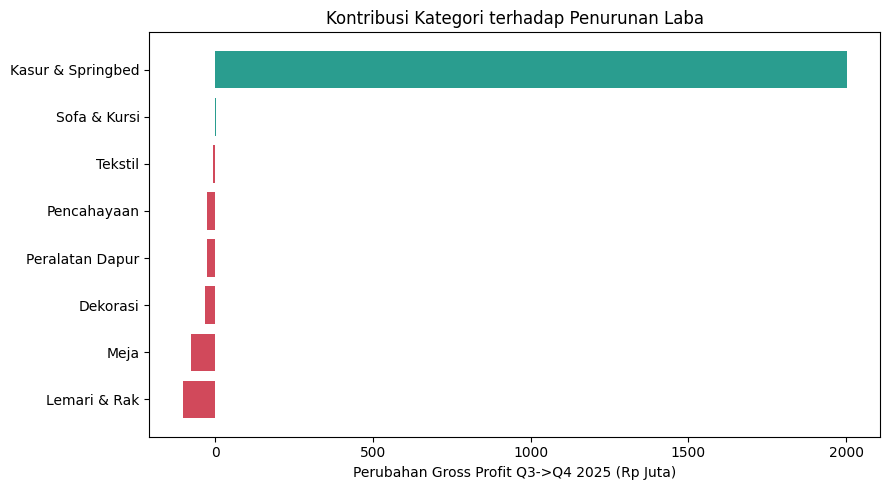

In [31]:
fig, ax = plt.subplots(figsize=(9,5))
colors = ['#d1495b' if v < 0 else '#2a9d8f' for v in impact['penurunan_profit']]
ax.barh(impact.index, impact['penurunan_profit']/1e6, color=colors)
ax.set_xlabel('Perubahan Gross Profit Q3->Q4 2025 (Rp Juta)')
ax.set_title('Kontribusi Kategori terhadap Penurunan Laba')
plt.tight_layout()
plt.show()

**Temuan Utama**:
Gross profit turun ~Rp367 juta dari Q3 ke Q4 2025.
Penurunan terbesar berasal dari Kasur & Springbed (33%), Lemari & Rak (24%), dan Meja (21%) — total hampir 80% penurunan.
Sofa & Kursi serta Dekorasi lebih tahan terhadap penurunan profit; Sofa & Kursi tetap menjadi penyumbang revenue terbesar.

## Pertanyaan 4: Apakah kanal online tetap menguntungkan setelah ongkos kirim dihitung?

In [32]:
online = comp[comp['channel']=='Online'].groupby('yq').agg(
    revenue=('revenue','sum'), gross_profit=('gross_profit','sum'),
    net_profit=('net_profit','sum'), shipping=('shipping_cost','sum')).reset_index()
online['gross_margin_%'] = online['gross_profit']/online['revenue']*100
online['net_margin_%'] = online['net_profit']/online['revenue']*100
online['ongkir_%_revenue'] = online['shipping']/online['revenue']*100
online

,yq,revenue,gross_profit,net_profit,shipping,gross_margin_%,net_margin_%,ongkir_%_revenue
0,2024-Q1,2.406712e+09,6.590792e+08,4.745432e+08,184536000.0,27.385043,19.717487,7.667556
1,2024-Q2,2.923693e+09,8.462211e+08,6.478111e+08,198410000.0,28.943568,22.157288,6.786280
2,2024-Q3,2.419663e+09,7.068574e+08,5.474364e+08,159421000.0,29.213048,22.624487,6.588561
3,2024-Q4,3.036054e+09,7.219385e+08,5.014345e+08,220504000.0,23.778839,16.515991,7.262847
4,2025-Q1,3.612749e+09,1.090379e+09,8.571273e+08,233252000.0,30.181426,23.725069,6.456357
5,2025-Q2,4.612751e+09,2.013762e+09,1.767271e+09,246491000.0,43.656422,38.312735,5.343687
6,2025-Q3,3.019658e+09,9.730905e+08,7.642755e+08,208815000.0,32.225194,25.310006,6.915188
7,2025-Q4,6.054396e+09,2.925340e+09,2.608921e+09,316418337.0,48.317615,43.091357,5.226258


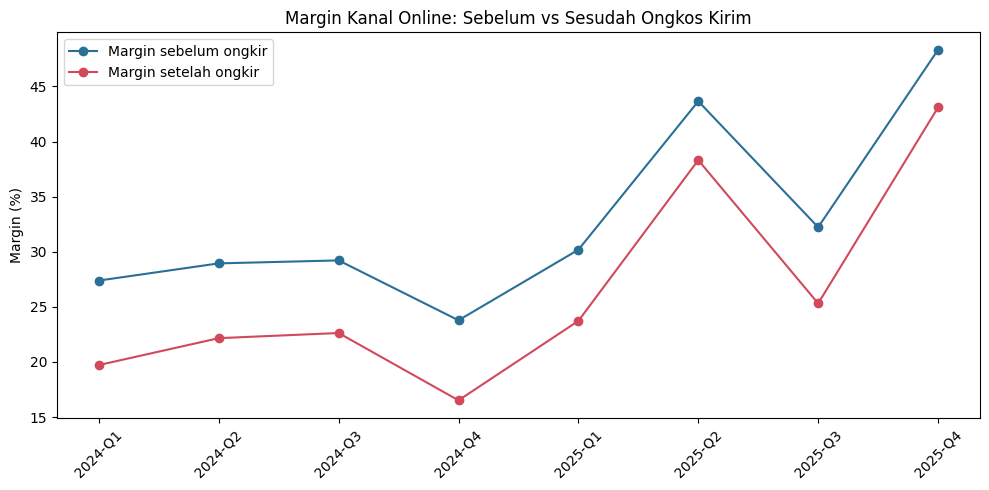

In [33]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(online['yq'], online['gross_margin_%'], marker='o', label='Margin sebelum ongkir', color='#2a6f97')
ax.plot(online['yq'], online['net_margin_%'], marker='o', label='Margin setelah ongkir', color='#d1495b')
ax.set_ylabel('Margin (%)')
ax.set_title('Margin Kanal Online: Sebelum vs Sesudah Ongkos Kirim')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Temuan Utama**:
Kanal online masih untung, tetapi sangat tipis di Q4 2025: net margin hanya 6,1%, turun dari 17,7% di Q3.
Ongkos kirim relatif stabil (6–7% revenue), sehingga bukan penyebab utama penurunan margin.
Masalah utamanya adalah diskon yang sudah menggerus gross margin, lalu masih harus dikurangi ongkir.
**Kesimpulan**: kanal online menjadi paling rentan; jika diskon makin besar atau ongkir naik sedikit saja, kanal ini berisiko masuk ke kondisi rugi.

## Pertanyaan 5: Tindakan apa yang paling cepat memulihkan margin tanpa membunuh volume?

**Rekomendasi untuk minggu depan:**

1. **Turunkan cap diskon dari ~20-23% menjadi ~12-15%**, terutama untuk kategori yang paling terdampak (Kasur & Springbed, Lemari & Rak, Meja) dan untuk kanal Online. Ini kembali ke level diskon Q3 2025 yang masih menghasilkan margin ~27% dan tetap punya volume order yang sehat — jadi bukan berarti harus hapus diskon, cukup dikurangi kedalamannya.
2. **Ganti diskon flat/blanket dengan diskon bertingkat (tiered) atau per-kategori**, bukan pukul rata semua kategori 20%. Kategori dengan margin tipis (Peralatan Dapur, Lemari & Rak, Pencahayaan) sebaiknya dapat diskon lebih kecil dibanding kategori bermargin tebal (Dekorasi, Tekstil) yang masih aman didiskon dalam.
3. **Tinjau ulang struktur biaya ongkir untuk kanal Online** — walau saat ini stabil, kanal ini paling tipis marginnya sehingga paling berisiko; pertimbangkan subsidi ongkir minimum pembelian, bukan gratis ongkir tanpa syarat.
4. **Pantau margin bulanan (bukan hanya kuartalan)** untuk periode promo besar berikutnya, supaya kalau ada pola serupa saat kampanye akhir tahun berikutnya, koreksi bisa dilakukan di tengah jalan, bukan setelah satu kuartal penuh berlalu.